In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
content = pd.read_csv('House Price India.csv')
content.shape

(14620, 23)

In [3]:
content.head(9)

,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
0,6762810145,42491,5,2.50,3650,9050,2.0,0,4,5,...,1921,0,122003,52.8645,-114.557,2880,5400,2,58,2380000
1,6762810635,42491,4,2.50,2920,4000,1.5,0,0,5,...,1909,0,122004,52.8878,-114.470,2470,4000,2,51,1400000
2,6762810998,42491,5,2.75,2910,9480,1.5,0,0,3,...,1939,0,122004,52.8852,-114.468,2940,6600,1,53,1200000
3,6762812605,42491,4,2.50,3310,42998,2.0,0,0,3,...,2001,0,122005,52.9532,-114.321,3350,42847,3,76,838000
4,6762812919,42491,3,2.00,2710,4500,1.5,0,0,4,...,1929,0,122006,52.9047,-114.485,2060,4500,1,51,805000
5,6762813105,42491,3,2.50,2600,4750,1.0,0,0,4,...,1951,0,122007,52.9133,-114.590,2380,4750,1,67,790000
6,6762813157,42491,5,3.25,3660,11995,2.0,0,2,3,...,2006,0,122008,52.7637,-114.050,3320,11241,3,72,785000
7,6762813599,42491,3,1.75,2240,10578,2.0,0,0,5,...,1923,0,122006,52.9254,-114.482,1570,10578,3,71,750000
8,6762813600,42491,3,2.50,2390,6550,1.0,0,2,4,...,1955,0,122009,52.8014,-114.598,2010,6550,1,73,750000


<Axes: >

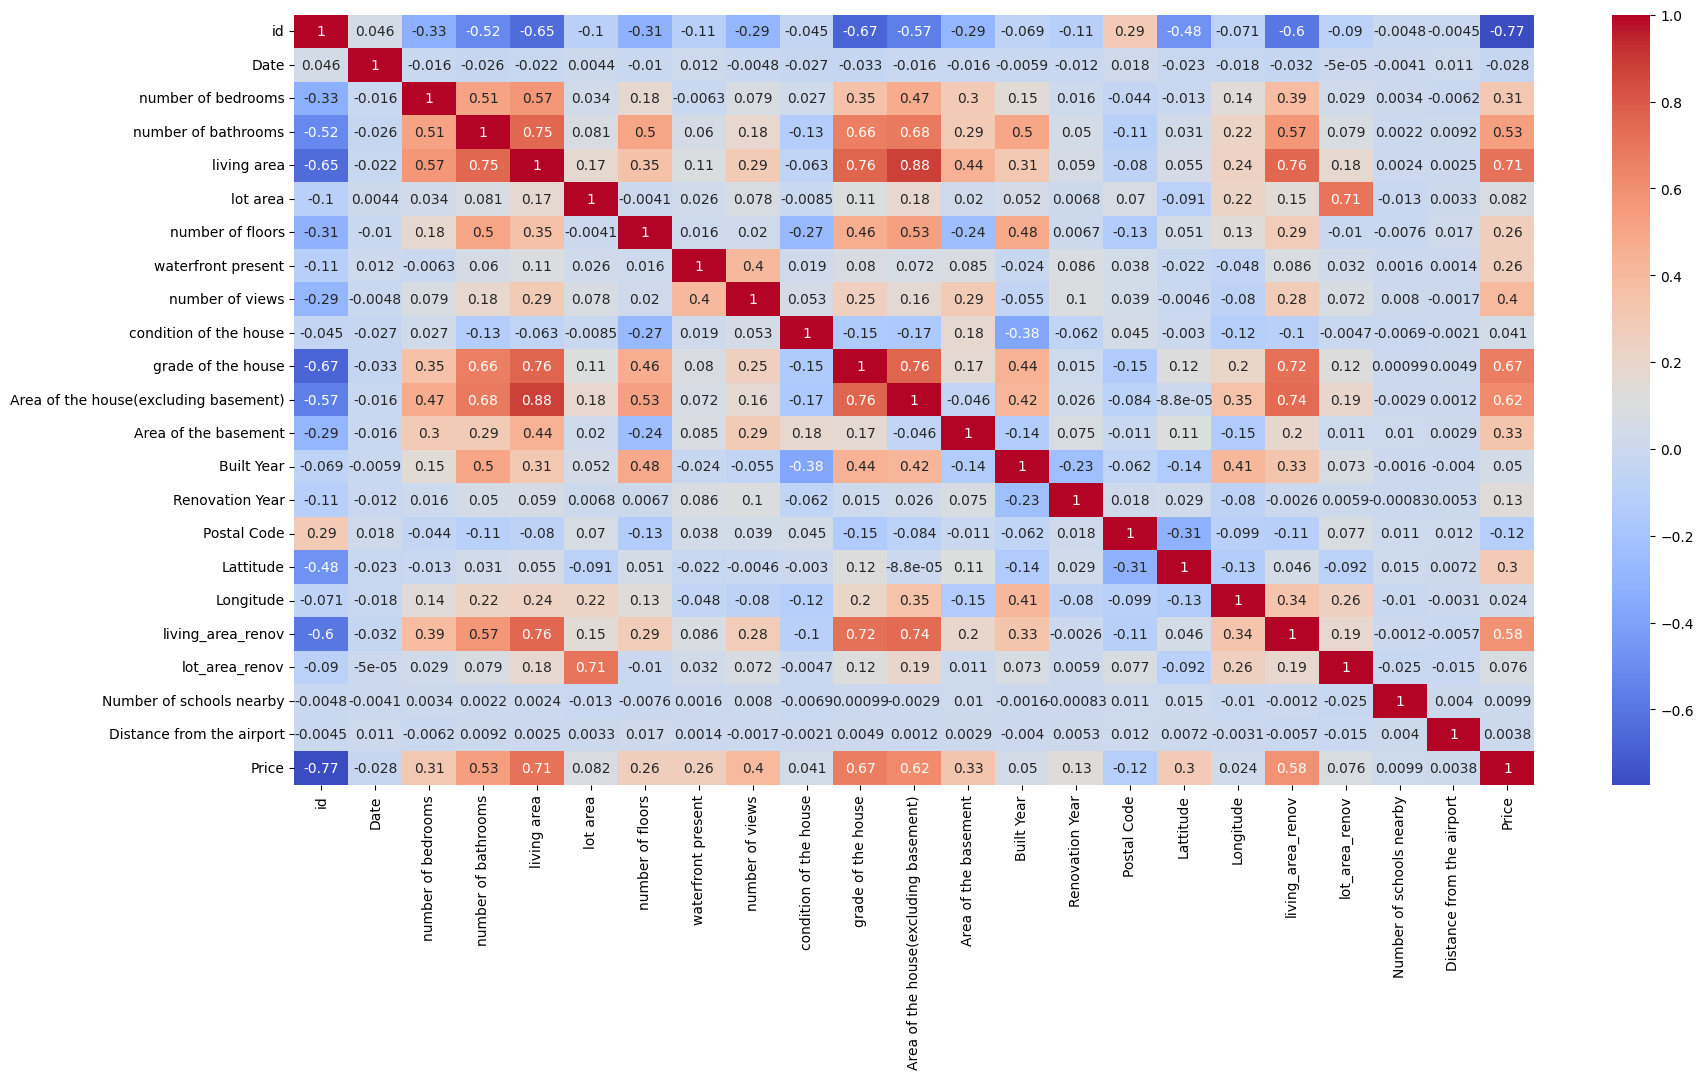

In [4]:
corr =content.corr()
plt.figure(figsize=(20,10))
sns.heatmap(corr, annot=True, cmap='coolwarm')

In [5]:
X = content.drop(['Price','id','Date','lot area','Area of the house(excluding basement)','Area of the basement','waterfront present',	'number of views','Built Year','Longitude','Postal Code',	'lot_area_renov','Number of schools nearby','Distance from the airport'], axis=1)
content['Price'] = np.log1p(content['Price'])
y=content['Price']
X

,number of bedrooms,number of bathrooms,living area,number of floors,condition of the house,grade of the house,Renovation Year,Lattitude,living_area_renov
0,5,2.50,3650,2.0,5,10,0,52.8645,2880
1,4,2.50,2920,1.5,5,8,0,52.8878,2470
2,5,2.75,2910,1.5,3,8,0,52.8852,2940
3,4,2.50,3310,2.0,3,9,0,52.9532,3350
4,3,2.00,2710,1.5,4,8,0,52.9047,2060
...,...,...,...,...,...,...,...,...,...
14615,2,1.50,1556,1.0,4,7,0,52.6191,2250
14616,3,2.00,1680,1.5,4,7,0,52.5075,1540
14617,2,1.00,1070,1.0,3,6,0,52.7289,1130
14618,4,1.00,1030,1.0,4,6,0,52.7157,1420


In [6]:
y.head()

0    14.682611
1    14.151984
2    13.997833
3    13.638775
4    13.598599
Name: Price, dtype: float64

In [7]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [8]:
from lightgbm import LGBMRegressor

model = LGBMRegressor()
model.fit(X_train, y_train)
print()
model.score(X_train,y_train),model.score(X_test,y_test)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001777 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 876
[LightGBM] [Info] Number of data points in the train set: 11696, number of used features: 9
[LightGBM] [Info] Start training from score 13.046712



(0.890605078449438, 0.8491913588450362)

In [12]:
pred =model.predict([[5,2.50,3650,2.0,5,10,0,52.8645,2880]])
np.expm1(pred)

C:\Users\NSK\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


array([1670577.72032894])

In [9]:
import pickle
pickle.dump(model,open('model.pkl','wb'))


In [14]:
f=open('model.pkl','rb')
model = pickle.load(f)
pred =model.predict([[5,2.50,3650,2.0,5,10,0,52.8645,2880]])
np.expm1(pred)[0]

C:\Users\NSK\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


np.float64(1670577.720328942)